# 02 — EDA (Exploratory Data Analysis)

**Objetivo:** Entender o comportamento dos dados limpos, identificar padroes e gerar insights que respondam a pergunta central do projeto:

> *Quais fatores estao associados a maior probabilidade de um paciente nao comparecer a sua consulta?*

**Input:** `../data/processed/appointments_clean.csv` (gerado pelo `01_etl.ipynb`)

## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline

## Setting Paths

In [2]:
DATAPATH = "../data/processed/"
DATAFILE_NAME = os.path.join(DATAPATH, "appointments_clean.csv")
data = pd.read_csv(DATAFILE_NAME)
display(data)
print(f"Shape: {data.shape}")

,Unnamed: 0,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,entry_service_date,city,...,appointment_month,appointment_year,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,rain_intensity,heat_intensity,icd_description
0,0,physiotherapy,13:20,M,2021-09-09,1,surto,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
1,1,psychotherapy,13:20,M,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
2,2,speech therapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
3,3,physiotherapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
4,4,physiotherapy,14:00,M,2021-09-09,0,NaN,motor,2020-02-05,B. CAMBORIU,...,sept,2021,afternoon,68.0,0,1,1,no_rain,mild,Other cerebrovascular diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,49588,NaN,10:20,M,2022-02-01,1,pai tem médico,intellectual,2019-11-05,ITAJAÍ,...,feb,2022,morning,13.0,0,0,0,no_rain,heavy_cold,Asperger syndrome
49589,49589,NaN,10:20,M,2022-02-01,1,NaN,NaN,NaN,NaN,...,feb,2022,morning,NaN,0,0,0,no_rain,heavy_cold,NaN
49590,49590,NaN,11:00,M,2022-02-01,0,NaN,intellectual,2020-02-11,BOMBINHAS,...,feb,2022,morning,6.0,1,0,1,no_rain,heavy_cold,Pervasive developmental disorders
49591,49591,psychotherapy,11:00,M,2022-02-01,1,NaN,NaN,NaN,NaN,...,feb,2022,morning,NaN,0,0,0,no_rain,heavy_cold,NaN


Shape: (49593, 21)


## 1. Data Quality

> Antes de qualquer analise, precisamos entender o estado dos dados: o que esta faltando, o que esta desbalanceado, o que pode distorcer os resultados.
>
> **Por que isso importa:** analises feitas sobre dados com muitos nulos podem gerar conclusoes enganosas. Precisamos saber onde pisar com cuidado.

### 1.1 Nulls per Column

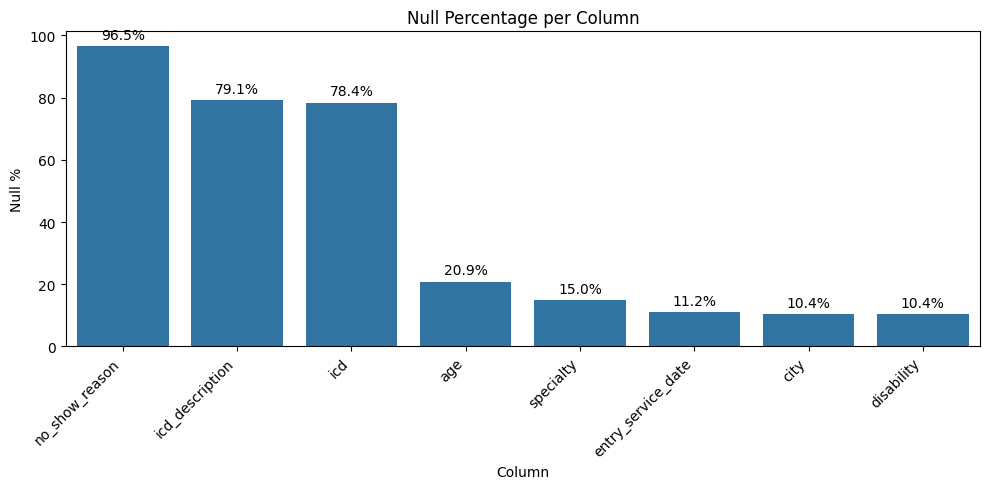

,total_nulls,percentage
no_show_reason,47856,96.50
icd_description,39240,79.12
icd,38876,78.39
age,10350,20.87
specialty,7454,15.03
entry_service_date,5549,11.19
city,5181,10.45
disability,5137,10.36


In [3]:
nulls = data.isnull().sum()
nulls_pct = (nulls / len(data) * 100).round(2)
null_df = pd.DataFrame({"total_nulls": nulls, "percentage": nulls_pct})
null_df = null_df[null_df["total_nulls"] > 0].sort_values("percentage", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=null_df.reset_index(), x="index", y="percentage", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.xticks(rotation=45, ha="right")
plt.title("Null Percentage per Column")
plt.xlabel("Column")
plt.ylabel("Null %")
plt.tight_layout()
plt.show()

display(null_df)

### 1.2 Class Imbalance (Target Variable)

C:\Users\Linek\AppData\Local\Temp\ipykernel_19132\2358963747.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


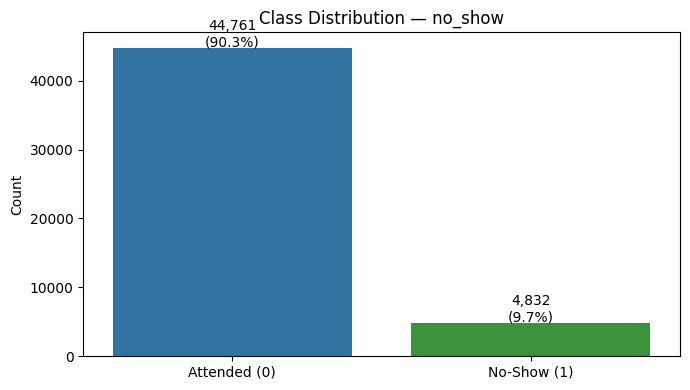


AVISO: O dataset e altamente desbalanceado (~90% attended vs ~10% no-show).
Isso impacta diretamente a escolha de metricas na modelagem:
- Accuracy sera enganosa (um modelo que sempre prediz '0' teria 90% de accuracy)
- Devemos usar F1-Score, ROC-AUC e Precision-Recall como metricas principais



In [4]:
counts = data["no_show"].value_counts()
pcts = data["no_show"].value_counts(normalize=True).round(3) * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=["Attended (0)", "No-Show (1)"], y=counts.values, palette=["C0", "C2"], ax=ax
)
for i, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, cnt + 200, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=10)
plt.title("Class Distribution — no_show")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("""
AVISO: O dataset e altamente desbalanceado (~90% attended vs ~10% no-show).
Isso impacta diretamente a escolha de metricas na modelagem:
- Accuracy sera enganosa (um modelo que sempre prediz '0' teria 90% de accuracy)
- Devemos usar F1-Score, ROC-AUC e Precision-Recall como metricas principais
""")

### 1.3 Inconsistent Dates

In [5]:
appt = pd.to_datetime(data["appointment_date"], errors="coerce")
entry = pd.to_datetime(data["entry_service_date"], errors="coerce")
inconsistent = (entry > appt).sum()
print(f"Registros com entry_service_date DEPOIS da appointment_date: {inconsistent}")
print(
    "Esses registros tem inconsistencia de origem (provavel erro de digitacao na clinica)."
)
print("Serao tratados na Feature Engineering antes da modelagem.")

Registros com entry_service_date DEPOIS da appointment_date: 827
Esses registros tem inconsistencia de origem (provavel erro de digitacao na clinica).
Serao tratados na Feature Engineering antes da modelagem.


### Conclusao — Data Quality

> - **`no_show_reason` (96.5% nulo)** e **`icd` (78.4% nulo)**: nao podem ser usadas como features confiaveis no modelo. As analises com essas colunas serao feitas com a ressalva de que representam uma minoria dos registros.
> - **`age` (20.9% nulo)**: afeta a analise demografica. Os graficos de faixa etaria refletem apenas ~79% dos pacientes.
> - **Desbalanceamento 90/10**: esperado para problemas de no-show. Sera tratado com tecnicas especificas na modelagem (ex: `class_weight`, SMOTE).
> - **827 datas inconsistentes**: registros validos para EDA, mas que serao filtrados ou corrigidos antes da modelagem.

## 2. Demographic Analysis

### 2.1 No-Show Rate by Gender

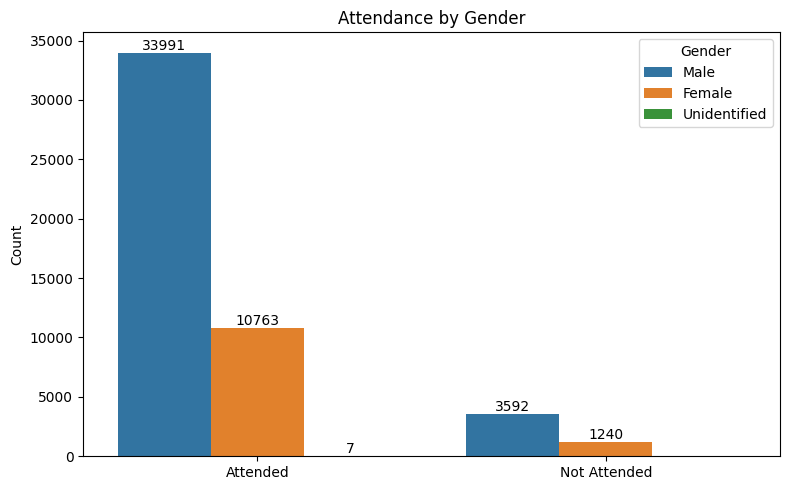

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="no_show", hue="gender")
ax = plt.gca()
handles, _ = ax.get_legend_handles_labels()
labels = ["Male", "Female", "Unidentified"]
ax.legend(handles=handles, labels=labels, title="Gender")
plt.xticks(ticks=[0, 1], labels=["Attended", "Not Attended"])
plt.title("Attendance by Gender")
plt.xlabel("")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()

### 2.2 No-Show Rate by Age Group

C:\Users\Linek\AppData\Local\Temp\ipykernel_19132\2569510863.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("age_group")["no_show"]
C:\Users\Linek\AppData\Local\Temp\ipykernel_19132\2569510863.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_volume = data.groupby("age_group").size().reset_index(name="total")


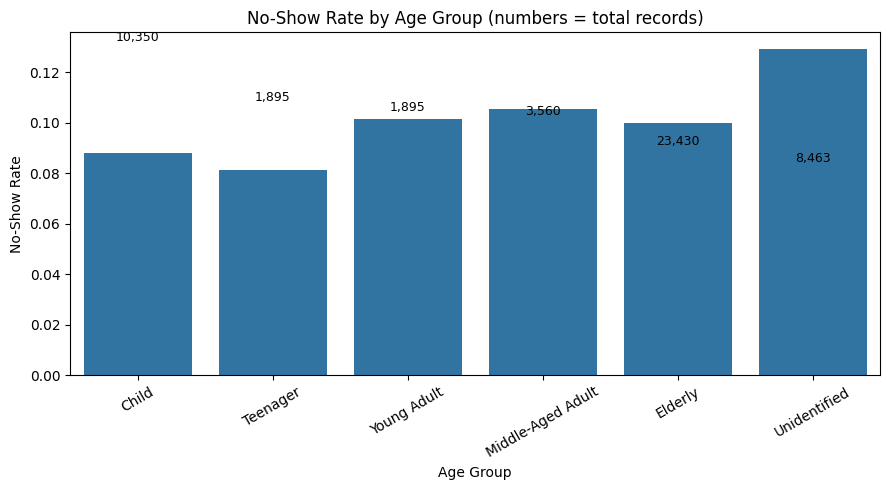

In [ ]:
age_numeric = pd.to_numeric(data["age"], errors="coerce")
data["age_group"] = pd.cut(
    age_numeric,
    bins=[0, 12, 19, 39, 59],
    labels=["Child", "Teenager", "Young Adult", "Middle-Aged Adult"],
)
data["age_group"] = data["age_group"].cat.add_categories(["Elderly", "Unidentified"])
data.loc[age_numeric >= 60, "age_group"] = "Elderly"
data.loc[pd.isna(age_numeric), "age_group"] = "Unidentified"

age_rate = (
    data.groupby("age_group")["no_show"]
    .mean()
    .reset_index(name="rate")
    .sort_values("rate", ascending=False)
)
age_volume = data.groupby("age_group").size().reset_index(name="total")
age_summary = age_rate.merge(age_volume, on="age_group")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=age_summary, x="age_group", y="rate")
for i, row in age_summary.iterrows():
    ax.text(
        i,
        row["rate"] + 0.002,
        f'{row["total"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.title("No-Show Rate by Age Group (numbers = total records)")
plt.xticks(rotation=30)
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate")
plt.tight_layout()
plt.show()

### Conclusao — Demographics

> *(Preencher apos analise: quais grupos apresentam maior taxa de no-show? Essa diferenca e relevante para o problema de negocio?)*

## 3. Temporal Analysis

### 3.1 No-Show Seasonality by Month

C:\Users\Linek\AppData\Local\Temp\ipykernel_7724\2567669932.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")


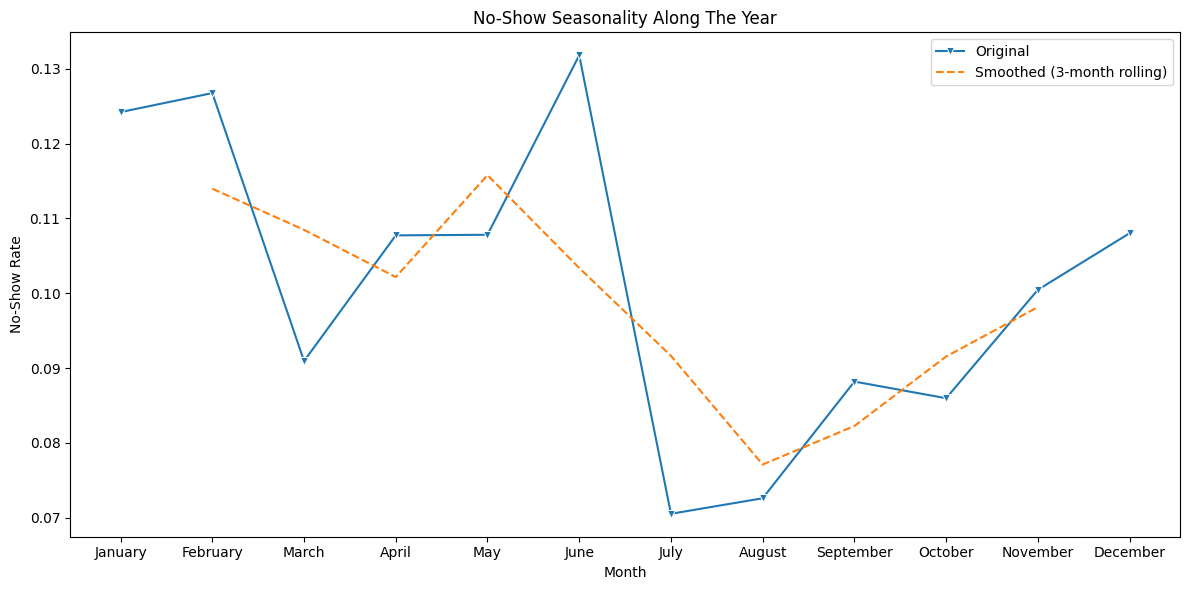

In [8]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
data["appointment_month"] = pd.to_datetime(
    data["appointment_date"], errors="coerce"
).dt.month_name()
data["appointment_month"] = pd.Categorical(
    data["appointment_month"], categories=month_order, ordered=True
)

monthly_rate = (
    data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")
)
monthly_rate["smooth"] = monthly_rate["rate"].rolling(3, center=True).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_rate, x="appointment_month", y="rate", marker="v", label="Original"
)
sns.lineplot(
    data=monthly_rate,
    x="appointment_month",
    y="smooth",
    linestyle="--",
    label="Smoothed (3-month rolling)",
)
plt.ylabel("No-Show Rate")
plt.xlabel("Month")
plt.title("No-Show Seasonality Along The Year")
plt.tight_layout()
plt.show()

### 3.2 No-Show Rate by Shift x Age Group

C:\Users\Linek\AppData\Local\Temp\ipykernel_7724\1235058424.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["appointment_shift", "age_group"])["no_show"]


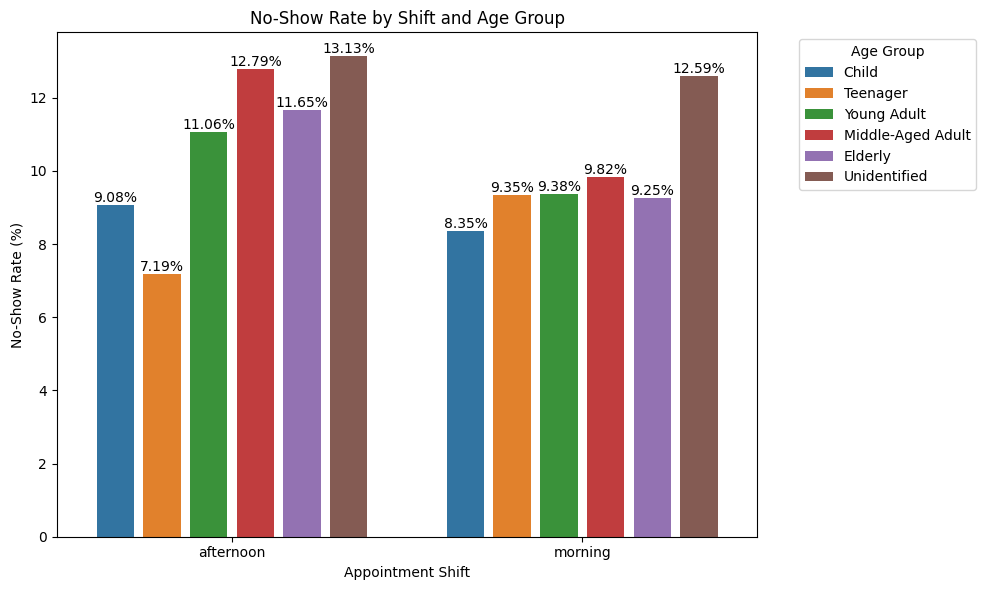

In [9]:
data["day_of_the_week"] = pd.to_datetime(
    data["appointment_date"], errors="coerce"
).dt.day_name()

shift_time = (
    data.groupby(["appointment_shift", "age_group"])["no_show"]
    .mean()
    .reset_index(name="rate")
)
shift_time["rate"] = round(shift_time["rate"] * 100, 2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=shift_time, x="appointment_shift", y="rate", hue="age_group", ax=ax, gap=0.2
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
ax.set_ylabel("No-Show Rate (%)")
ax.set_xlabel("Appointment Shift")
ax.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("No-Show Rate by Shift and Age Group")
plt.tight_layout()
plt.show()

### 3.3 No-Show by Day of Week (Top Risk Groups)

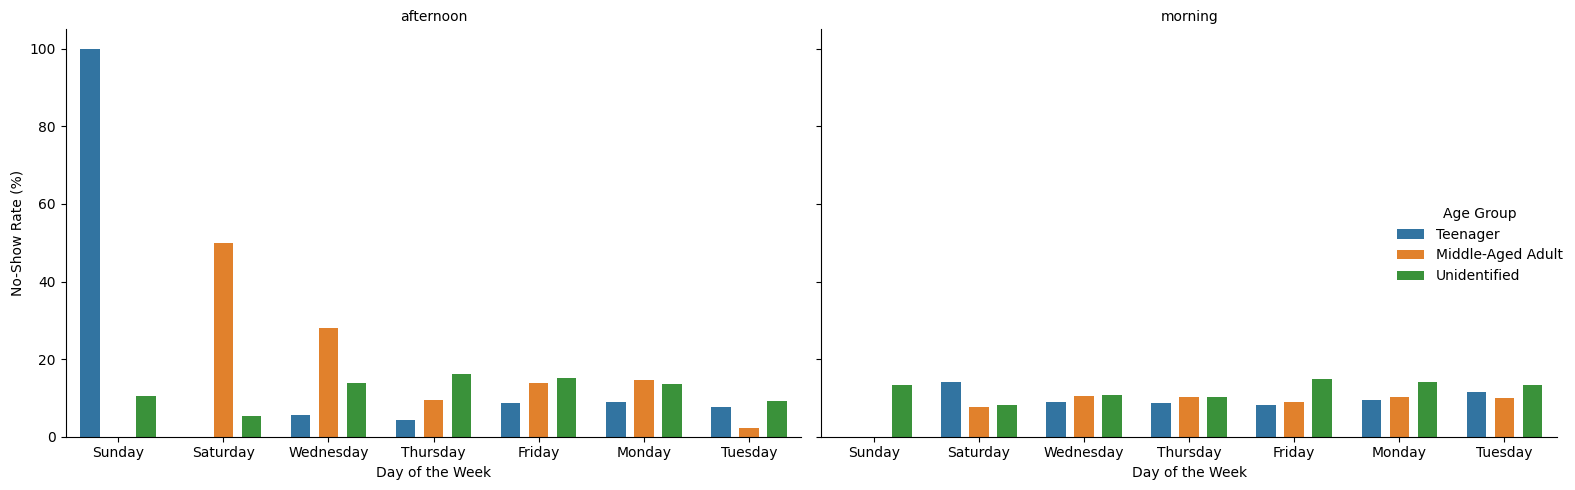

In [10]:
mask = data[
    (data["age_group"] == "Unidentified")
    | (data["age_group"] == "Middle-Aged Adult")
    | (data["age_group"] == "Teenager")
].index
df2 = data.loc[mask, ["age_group", "day_of_the_week", "no_show", "appointment_shift"]]
df2 = df2.copy()
df2["age_group"] = df2["age_group"].cat.remove_unused_categories()
df_day = (
    df2.groupby(["age_group", "day_of_the_week", "appointment_shift"], observed=True)[
        "no_show"
    ]
    .mean()
    .reset_index()
    .rename(columns={"no_show": "percentage"})
    .sort_values(by="percentage", ascending=False)
)
df_day["percentage"] = round(df_day["percentage"] * 100, 2)

g = sns.catplot(
    data=df_day,
    x="day_of_the_week",
    y="percentage",
    hue="age_group",
    col="appointment_shift",
    kind="bar",
    height=5,
    gap=0.3,
    aspect=1.4,
)
g.set_titles("{col_name}")
if g._legend is not None:
    g._legend.set_title("Age Group")
g.set_axis_labels("Day of the Week", "No-Show Rate (%)")
plt.tight_layout()
plt.show()

### Conclusao — Temporal

> *(Preencher apos analise: ha sazonalidade clara? Quais turnos e dias concentram mais no-show?)*

## 4. Medical Analysis

### 4.1 No-Show Rate by ICD Description

> **Atencao:** apenas 21.6% dos registros possuem CID preenchido. Os resultados abaixo representam uma minoria dos pacientes e devem ser interpretados com cautela.

C:\Users\Linek\AppData\Local\Temp\ipykernel_7724\2579881677.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


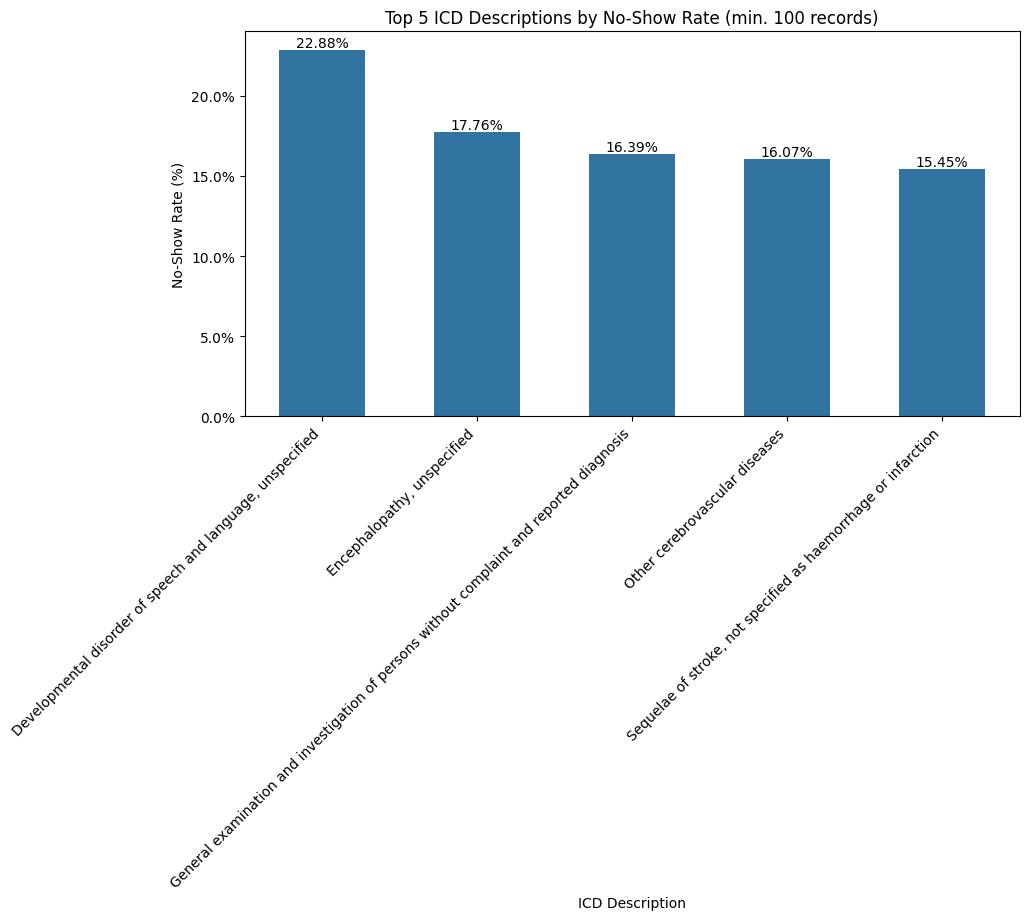

: 

In [ ]:
icd_description_list = data["icd_description"].value_counts()
icd_description_list = icd_description_list[icd_description_list >= 100].index
df_icd = data[data["icd_description"].isin(icd_description_list)]
df_icd = (
    df_icd.groupby("icd_description", as_index=False)["no_show"]
    .mean()
    .rename(columns={"no_show": "rate"})
    .sort_values(by="rate", ascending=False)
    .head(5)
)
df_icd["rate"] = (df_icd["rate"] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_icd, x="icd_description", y="rate", gap=0.3, ax=ax)
ax.bar_label(ax.containers[0], fmt="%.2f%%")
plt.xticks(rotation=45, ha="right")
plt.xlabel("ICD Description")
plt.ylabel("No-Show Rate (%)")
plt.title("Top 5 ICD Descriptions by No-Show Rate (min. 100 records)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

### 4.2 No-Show Rate by Specialty

In [ ]:
specialty_rate = (
    data.groupby("specialty")["no_show"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "rate", "count": "total"})
)
specialty_rate = specialty_rate[specialty_rate["total"] >= 100].sort_values("rate", ascending=False).head(10)
specialty_rate["rate"] = (specialty_rate["rate"] * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=specialty_rate, x="specialty", y="rate", ax=ax)
for i, row in specialty_rate.reset_index().iterrows():
    ax.text(i, row["rate"] + 0.3, f'{row["total"]:,}', ha="center", fontsize=8)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=12)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Specialty")
plt.ylabel("No-Show Rate (%)")
plt.title("Top 10 Specialties by No-Show Rate (min. 100 records, numbers = total)")
plt.tight_layout()
plt.show()

### 4.3 No-Show Reason Analysis

In [ ]:
reasons = data["no_show_reason"].dropna()
print(f"Registros com no_show_reason preenchido: {len(reasons)} ({len(reasons)/len(data)*100:.1f}%)")

reason_counts = reasons.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=reason_counts.values, y=reason_counts.index, ax=ax, orient="h")
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.title("Top 10 No-Show Reasons (3.5% of records)")
plt.xlabel("Count")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

print("\nAVISO: com 96.5% de nulos, essa coluna nao pode ser usada como feature no modelo.")
print("Serve apenas como referencia qualitativa para entendimento do problema.")

### Conclusao — Medical Analysis

> *(Preencher apos analise: ha especialidades com taxa de no-show significativamente maior? Quais CIDs se destacam?)*

## 5. Overall Conclusions

> *(Preencher ao final do EDA com os 3-5 principais achados que serao levados para a modelagem)*
>
> Exemplo de estrutura:
> - **Fator 1:** ...
> - **Fator 2:** ...
> - **Features mais promissoras para o modelo:** ...